# Beer Expert Panel (Supplementary File S1 + S4)  
## High-dimensional Small Data Synthetic Generation & True-Manifold Preservation Experiments (4090 eGPU)

이 노트북은 업로드된 **`Supplemental Files and Figure source files.xlsx`**를 직접 읽어,
- **X (Chemistry features)**: `Supplementary File S1`의 `acetaldehyde` ~ `sulfur_sum` (231 features)
- **Y (Expert sensory panel)**: `Supplementary File S4`의 `A_malt_all` ~ `overall` (50 targets, 선택적으로 `overall`만 사용 가능)
- **RateBeer(일반인 리뷰) 데이터는 사용하지 않음**

을 전제로 합니다.

---

## 실험 목적
High-dimensional small data (N≈250, D≈231)에서,
- **Baselines**: Bootstrapping / Independent KDE / Gaussian Copula  
- **Generative AI**: VAE (직접 구현, GPU/AMP 최적화) / CTGAN (설치되어 있으면)  
를 비교하고,

논문에서 요구한 2-phase 평가를 수행합니다.

### Phase 1 — Validity & Fidelity
1) KS-test (feature-wise)  
2) PCD (Pairwise Correlation Difference; 상관행렬 차이)  
3) DCR (Distance to Closest Record; memorization/outlier 점검)

### Phase 2 — Utility (TSTR)
- Train on Synthetic, Test on Real  
- Regressor: **Torch MLP (GPU)** 기본, **XGBoost (GPU 가능 시)** 옵션  
- Metrics: R², RMSE

---

## 4090 eGPU 최적화
- PyTorch: CUDA + AMP(BF16/FP16)  
- DCR: `torch.cdist`로 GPU에서 chunk 계산  
- (Small N 특성상 GPU가 놀 수 있어) `N_SYNTH`를 늘리거나 seed 반복을 하면 GPU 활용도가 올라갑니다.

## 0. 경로 설정
당신 PC 폴더:
`C:\Users\eys63\Desktop\맥주데이터실험\data`

아래 `DATA_PATH`만 맞추면 됩니다.

In [1]:

from pathlib import Path

DATA_DIR  = Path(r"C:\Users\eys63\Desktop\맥주데이터실험\data")
DATA_PATH = DATA_DIR / "Supplemental Files and Figure source files.xlsx"

# fallback: 현재 노트북과 같은 폴더에 파일을 둔 경우
if not DATA_PATH.exists():
    alt = Path("Supplemental Files and Figure source files.xlsx")
    if alt.exists():
        DATA_PATH = alt

print("DATA_PATH:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

# 폴더 파일 목록(참고)
if DATA_DIR.exists():
    for p in sorted(DATA_DIR.glob("*")):
        print(p.name)

DATA_PATH: C:\Users\eys63\Desktop\맥주데이터실험\data\Supplemental Files and Figure source files.xlsx
Exists: True
10653704.zip
init_modeling.py
Jupyter Notebook for training machine learning models.ipynb
Machine learning models transcript.py
Main Figure Generator.Rmd
Partial Dependence Plots with SHAP.ipynb
RateBeer_Appreciation_Gradient_Boost_Regressor.pkl
RateBeer_Full_Model_Gradient_Boost_Regressor.pkl
README.txt
Sensory data quality control - ANOVA on repeated samples.Rmd
SHAP analysis.ipynb
Supplemental Figure generator.Rmd
Supplemental Files and Figure source files.xlsx


## 1. Import + 4090 eGPU / CUDA / AMP 설정
- Python 3.8+ 호환 (타입힌트에서 `str | None` 같은 3.10+ 문법 사용 안 함)

In [2]:

import os, math, time, random
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.covariance import LedoitWolf
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    # TF32 / matmul precision
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

USE_AMP = (DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))
print("USE_AMP =", USE_AMP, "| AMP_DTYPE =", AMP_DTYPE, "| GradScaler enabled =", SCALER.is_enabled())

DEVICE = cuda
GPU: NVIDIA GeForce RTX 4090
VRAM(GB): 25.756696576
USE_AMP = True | AMP_DTYPE = torch.bfloat16 | GradScaler enabled = False


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\646322158.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(enabled=(USE_AMP and AMP_DTYPE == torch.float16))


## 2. 데이터 로드 (S1: chemistry, S4: expert sensory panel)
- sheet name은 실제 파일에 존재하는 고정 이름:
  - `Supplementary File S1`
  - `Supplementary File S4`

In [3]:

xls = pd.ExcelFile(DATA_PATH)
print("Sheets:", len(xls.sheet_names))
print(xls.sheet_names)

S1_SHEET = "Supplementary File S1"
S4_SHEET = "Supplementary File S4"

chem = xls.parse(S1_SHEET)
panel = xls.parse(S4_SHEET)

print("chem shape :", chem.shape)
print("panel shape:", panel.shape)

display(chem.head(3))
display(panel.head(3))

Sheets: 29
['Supplementary File S1', 'Supplementary File S2', 'Supplementary File S3', 'Supplementary File S4', 'Supplementary File S5', 'Supplementary File S6', 'Supplementary File S7', 'Supplementary Table S1', 'Supplementary Table S2', 'Supplementary Table S3', 'Supplementary Table S4', 'Supplementary Table S5', 'Supplementary Table S6', 'Supplementary Table S7', 'Sensory thresholds', 'Sensory names', 'Validation Results 1', 'Validation Results 2', 'Validation Results 3', 'Validation Concentrations', 'Validation Details', 'GBM importance MDI', 'GBM SHAP Values', 'Calibrated chemical dataset', 'Beer Prices', 'Performance of 100 models', '100 models feature importance', 'GBM model on merged dataset', 'GBM model with style informatio']
chem shape : (250, 234)
panel shape: (250, 53)


,beer,beer_id,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,...,X13.epi.manool.oxide,isopropyl.hexadecanoate,manool,ethyl.octadecanoate,ethyl.pentanoate,X2.ethyl.3.methylpyrazine,esters_sum,aroma_hops_sum,acids_sum,sulfur_sum
0,10,5410228202929,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,...,4.360243,-1.817819,5.721204,4.438951,0.014728,0.054353,-0.532634,3.696586,0.244085,0.166286
1,86,5410783031019,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,...,4.512589,4.323292,5.810501,4.247826,0.023167,0.001400,-0.465401,1.219563,-0.152156,0.098931
2,2,5410228142003,Low/No alcohol,0.511067,-2.146292,-1.905267,0.898604,-3.19552,-0.134514,-1.893639,...,4.394267,-1.817819,5.585529,3.598293,0.017571,0.000699,-0.409346,1.148974,-0.161504,-0.022943


,beer,beer_id,tasting_category_fine,A_malt_all,A_malt_grain,A_malt_bread,A_malt_cara,A_malt_burn,A_hops_all,A_hops_citrus,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
0,10,5410228202929,Low/No alcohol,-0.481208,-0.179070,-0.464636,-0.554391,-0.38454,-0.022010,0.843613,...,0.783631,2.828355,-0.162975,-0.282149,-0.35729,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
1,86,5410783031019,Low/No alcohol,1.678276,1.759243,0.356967,0.649475,0.68797,-0.735573,-0.493721,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806
2,2,5410228142003,Low/No alcohol,-0.135865,0.215999,-0.083786,-0.554391,-0.38454,-1.192019,-0.493721,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.35729,-1.990725,-1.647121,-1.169839,-1.353028,-1.528544


## 3. X / Y 컬럼 선택 (논문/저자 노트북과 동일한 범위)
- X: `acetaldehyde` ~ `sulfur_sum` (S1 내부)
- Y: `A_malt_all` ~ `overall` (S4 내부)
- join key: `beer_id` (250개 모두 unique)

> 타겟은 기본적으로 50개 전체를 사용합니다.  
> 빠르게 실험하고 싶으면 `TARGET_MODE="overall"`로 바꾸세요.

In [4]:

def slice_range_columns(cols, start, end):
    cols = list(cols)
    if (start not in cols) or (end not in cols):
        return []
    i0, i1 = cols.index(start), cols.index(end)
    if i0 <= i1:
        return cols[i0:i1+1]
    else:
        return cols[i1:i0+1]

# join on beer_id
assert chem["beer_id"].is_unique and panel["beer_id"].is_unique

chem = chem.set_index("beer_id")
panel = panel.set_index("beer_id")

# pull shared meta columns (style) from chem (or panel - same)
META_COLS = []
for c in ["beer", "tasting_category_fine"]:
    if c in chem.columns:
        META_COLS.append(c)

X_COLS = slice_range_columns(chem.columns, "acetaldehyde", "sulfur_sum")
Y_ALL  = slice_range_columns(panel.columns, "A_malt_all", "overall")

print("Meta cols:", META_COLS)
print("X_COLS:", len(X_COLS), "| first/last:", X_COLS[:3], "...", X_COLS[-3:])
print("Y_ALL :", len(Y_ALL),  "| first/last:", Y_ALL[:3],  "...", Y_ALL[-3:])

TARGET_MODE = "multi"   # "multi" or "overall"
if TARGET_MODE == "overall":
    Y_COLS = ["overall"]
else:
    Y_COLS = Y_ALL

df = chem[META_COLS + X_COLS].join(panel[Y_COLS], how="inner")
print("Merged df shape:", df.shape)
df.head()

Meta cols: ['beer', 'tasting_category_fine']
X_COLS: 231 | first/last: ['acetaldehyde', 'CS2', 'DES'] ... ['aroma_hops_sum', 'acids_sum', 'sulfur_sum']
Y_ALL : 50 | first/last: ['A_malt_all', 'A_malt_grain', 'A_malt_bread'] ... ['body', 'co2', 'overall']
Merged df shape: (250, 283)


,beer,tasting_category_fine,acetaldehyde,CS2,DES,DMS,ethyl_2.methyl_butyrate,ethyl_acetate,ethyl_decanoate,ethyl_hexanoate,...,coriander,clove,lactic,acetic,barnyard,alcohol,aftertaste,body,co2,overall
beer_id,,,,,,,,,,,,,,,,,,,,,
5410228202929,10,Low/No alcohol,-0.641741,-2.146292,-1.905267,0.046211,-3.19552,-0.599350,-1.975309,-2.476904,...,0.783631,2.828355,-0.162975,-0.282149,-0.357290,-1.807336,-1.682733,-0.630386,-1.043431,-0.467852
5410783031019,86,Low/No alcohol,-0.174824,-2.146292,-0.257098,0.347241,-3.19552,-0.507254,-1.755970,-2.175874,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-1.974904,-1.456136,-1.380574,-0.408753,-0.994806
5410228142003,2,Low/No alcohol,0.511067,-2.146292,-1.905267,0.898604,-3.19552,-0.134514,-1.893639,-2.129596,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-1.990725,-1.647121,-1.169839,-1.353028,-1.528544
54055520,83,Low/No alcohol,0.249793,-2.146292,-1.905267,0.782126,-3.19552,-0.233874,-2.086981,-1.868702,...,-0.213168,-0.225153,-0.314574,-0.282149,-0.357290,-2.150729,-1.801023,-0.997524,-1.045610,-0.934138
5410228141181,40,Low/No alcohol,-1.902829,-0.756987,-1.347270,0.553356,-3.19552,0.207751,-1.713095,-1.828127,...,-0.236605,-0.248292,-0.307380,-0.269671,-0.331149,-1.681082,-2.100345,-1.862278,-1.739428,-1.735965


## 4. 데이터 품질 체크 (Missing / Negative / Scale)
이 데이터는 일부 feature/target에 음수 값이 존재합니다(이미 어떤 변환/정규화가 적용된 것으로 보임).

따라서 사용자가 요구한 **log 변환**은 “그대로는 불가능”할 수 있어,
본 노트북은 두 가지 전처리 모드를 제공합니다.

- **MODE="minmax_only" (권장: paper-like)**  
  - 결측 mean-impute 후, MinMax만 수행  
- **MODE="shift_log1p_minmax" (요청사항 준수)**  
  - 각 컬럼별로 min이 0이 되도록 shift → log1p → MinMax  
  - reversible 하므로 synthetic을 원래 스케일로 복원 가능

논문에서 log가 정말 필요하다면(원시 GC peak가 long-tail인 경우) 두 번째 모드가 유용합니다.

In [5]:

X_raw = df[X_COLS].to_numpy(dtype=np.float32)
y_raw = df[Y_COLS].to_numpy(dtype=np.float32)

print("N, D_X, D_Y:", X_raw.shape[0], X_raw.shape[1], y_raw.shape[1])

def summarize_matrix(A, name):
    A = np.asarray(A)
    print(f"[{name}] min={np.nanmin(A):.4g}, max={np.nanmax(A):.4g}, mean={np.nanmean(A):.4g}, std={np.nanstd(A):.4g}, nan%={np.mean(np.isnan(A))*100:.3f}%")

summarize_matrix(X_raw, "X_raw")
summarize_matrix(y_raw, "y_raw")

neg_x = int(np.sum(np.nanmin(X_raw, axis=0) < 0))
neg_y = int(np.sum(np.nanmin(y_raw, axis=0) < 0))
print("Columns with negative values:", "X:", neg_x, "/", X_raw.shape[1], "| Y:", neg_y, "/", y_raw.shape[1])

missing_x = float(np.mean(np.isnan(X_raw)))
missing_y = float(np.mean(np.isnan(y_raw)))
print("Missing ratio:", "X:", missing_x, "| Y:", missing_y)

N, D_X, D_Y: 250 231 50
[X_raw] min=-4.487, max=1.26e+04, mean=3.512, std=68.56, nan%=0.126%
[y_raw] min=-2.151, max=6.172, mean=0.005428, std=0.5778, nan%=0.000%
Columns with negative values: X: 175 / 231 | Y: 50 / 50
Missing ratio: X: 0.0012640692640692641 | Y: 0.0


## 5. 전처리 클래스 (Impute + Transform + Inverse)
- `MODE="minmax_only"`: impute → MinMax  
- `MODE="shift_log1p_minmax"`: impute → shift → log1p → MinMax

In [6]:

class BeerPreprocessor:
    def __init__(self, mode="minmax_only"):
        assert mode in ["minmax_only", "shift_log1p_minmax"]
        self.mode = mode
        self.imputer_x = SimpleImputer(strategy="mean")
        self.imputer_y = SimpleImputer(strategy="mean")
        self.scaler_x = MinMaxScaler()
        self.scaler_y = MinMaxScaler()
        self.shift_ = None
        self.fitted_ = False

    def fit(self, X, y):
        X_imp = self.imputer_x.fit_transform(X)
        y_imp = self.imputer_y.fit_transform(y)

        if self.mode == "shift_log1p_minmax":
            min_per_col = np.min(X_imp, axis=0)
            self.shift_ = np.where(min_per_col < 0, -min_per_col, 0.0).astype(np.float32)
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            self.shift_ = np.zeros(X_imp.shape[1], dtype=np.float32)
            X2 = X_imp

        self.scaler_x.fit(X2)
        self.scaler_y.fit(y_imp)

        self.fitted_ = True
        return self

    def transform_X(self, X):
        assert self.fitted_
        X_imp = self.imputer_x.transform(X)
        if self.mode == "shift_log1p_minmax":
            X2 = np.log1p(np.clip(X_imp + self.shift_, 0, None))
        else:
            X2 = X_imp
        return self.scaler_x.transform(X2).astype(np.float32)

    def transform_y(self, y):
        assert self.fitted_
        y_imp = self.imputer_y.transform(y)
        return self.scaler_y.transform(y_imp).astype(np.float32)

    def inverse_transform_X(self, Xs):
        assert self.fitted_
        X2 = self.scaler_x.inverse_transform(Xs)
        if self.mode == "shift_log1p_minmax":
            X_imp = np.expm1(X2) - self.shift_
        else:
            X_imp = X2
        return X_imp.astype(np.float32)

    def inverse_transform_y(self, ys):
        assert self.fitted_
        return self.scaler_y.inverse_transform(ys).astype(np.float32)

## 6. Train/Test Split (stratify by tasting_category_fine if available)
Small data 환경이므로 stratify를 유지하는 것이 분산을 줄이는 데 도움이 됩니다.

In [7]:

strat = None
if "tasting_category_fine" in df.columns:
    strat = df["tasting_category_fine"].astype(str).values

MODE = "minmax_only"  # "minmax_only" (paper-like) or "shift_log1p_minmax" (requested log)
pre = BeerPreprocessor(mode=MODE)

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=strat
)

pre.fit(X_train, y_train)
X_train_s = pre.transform_X(X_train)
X_test_s  = pre.transform_X(X_test)
y_train_s = pre.transform_y(y_train)
y_test_s  = pre.transform_y(y_test)

print("Train shapes:", X_train_s.shape, y_train_s.shape)
print("Test  shapes:", X_test_s.shape, y_test_s.shape)

Train shapes: (200, 231) (200, 50)
Test  shapes: (50, 231) (50, 50)


## 7. Synthesizer 구현 (Baselines + VAE + CTGAN)
### Baselines
- Bootstrapping: 복원추출
- Independent KDE: 주변분포만 맞춤
- Gaussian Copula: 선형 상관구조(가우시안) 반영

### Proposed
- VAE: joint(X,y) 매니폴드 학습 (GPU/AMP)
- CTGAN: 설치되어 있으면 추가

In [8]:

class BaseSynthesizer:
    name = "BaseSynthesizer"
    def fit(self, Xs, ys):
        raise NotImplementedError
    def sample(self, n):
        raise NotImplementedError

class BootstrapSynthesizer(BaseSynthesizer):
    name = "Bootstrapping"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)
    def fit(self, Xs, ys):
        self.Xs = Xs
        self.ys = ys
        return self
    def sample(self, n):
        idx = self.rng.integers(0, len(self.Xs), size=n)
        return self.Xs[idx], self.ys[idx]

In [9]:

from sklearn.neighbors import KernelDensity

class IndependentKDESynthesizer(BaseSynthesizer):
    name = "IndependentKDE"
    def __init__(self, bandwidth=0.05, kernel="gaussian", seed=0):
        self.bandwidth = bandwidth
        self.kernel = kernel
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.models = []
        self.is_const = []
        self.const_val = []

        for j in range(Z.shape[1]):
            col = Z[:, [j]]
            if np.allclose(col, col[0]):
                self.models.append(None)
                self.is_const.append(True)
                self.const_val.append(float(col[0, 0]))
            else:
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(col)
                self.models.append(kde)
                self.is_const.append(False)
                self.const_val.append(0.0)
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Zs = np.zeros((n, d), dtype=np.float32)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                samp = self.models[j].sample(n_samples=n, random_state=int(self.rng.integers(0, 1_000_000)))
                Zs[:, j] = samp[:, 0]
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [10]:

def rank_to_u(x):
    n = len(x)
    ranks = stats.rankdata(x, method="average")
    u = (ranks - 0.5) / n
    return np.clip(u, 1e-6, 1-1e-6)

def make_psd_corr(C, eps=1e-6):
    w, V = np.linalg.eigh(C)
    w = np.clip(w, eps, None)
    Cp = (V * w) @ V.T
    d = np.sqrt(np.clip(np.diag(Cp), eps, None))
    Cp = Cp / np.outer(d, d)
    Cp[np.diag_indices_from(Cp)] = 1.0
    return Cp

def safe_quantile(data, q):
    # numpy version compatibility: method vs interpolation
    try:
        return np.quantile(data, q, method="linear")
    except TypeError:
        return np.quantile(data, q, interpolation="linear")

class GaussianCopulaSynthesizer(BaseSynthesizer):
    name = "GaussianCopula"
    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float64)

        self.is_const = np.zeros(Z.shape[1], dtype=bool)
        self.const_val = np.zeros(Z.shape[1], dtype=np.float64)

        U = np.zeros_like(Z)
        for j in range(Z.shape[1]):
            col = Z[:, j]
            if np.allclose(col, col[0]):
                self.is_const[j] = True
                self.const_val[j] = col[0]
                U[:, j] = 0.5
            else:
                U[:, j] = rank_to_u(col)

        G = norm.ppf(U)

        # shrinkage covariance -> correlation
        lw = LedoitWolf().fit(G)
        cov = lw.covariance_
        d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
        corr = cov / np.outer(d, d)
        corr[np.diag_indices_from(corr)] = 1.0
        self.corr = make_psd_corr(corr)
        self.Z_ref = Z
        return self

    def sample(self, n):
        d = self.d_x + self.d_y
        Gs = self.rng.multivariate_normal(mean=np.zeros(d), cov=self.corr, size=n)
        U = norm.cdf(Gs)

        Zs = np.zeros((n, d), dtype=np.float64)
        for j in range(d):
            if self.is_const[j]:
                Zs[:, j] = self.const_val[j]
            else:
                Zs[:, j] = safe_quantile(self.Z_ref[:, j], U[:, j])

        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0).astype(np.float32)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [11]:

class TabularVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=24, hidden=(512, 256), dropout=0.05):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        enc = []
        d = input_dim
        for h in hidden:
            enc += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        self.encoder = nn.Sequential(*enc)
        self.fc_mu = nn.Linear(d, latent_dim)
        self.fc_logvar = nn.Linear(d, latent_dim)

        dec = []
        d = latent_dim
        for h in reversed(hidden):
            dec += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        dec += [nn.Linear(d, input_dim)]
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))  # scaled data in [0,1]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

class VAESynthesizer(BaseSynthesizer):
    name = "VAE"
    def __init__(self, latent_dim=24, hidden=(512,256), beta=0.5, lr=2e-3, wd=1e-4,
                 max_epochs=800, batch_size=64, patience=80, noise_std=0.01, seed=0):
        self.latent_dim = latent_dim
        self.hidden = hidden
        self.beta = beta
        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience
        self.noise_std = noise_std
        self.seed = seed

    def fit(self, Xs, ys):
        seed_everything(self.seed)
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1).astype(np.float32)

        Zt = torch.from_numpy(Z).to(DEVICE)  # eGPU: move once

        # train/val split
        n = Zt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx = idx[:n_val]
        tr_idx  = idx[n_val:]
        Ztr, Zva = Zt[tr_idx], Zt[val_idx]

        self.model = TabularVAE(Z.shape[1], latent_dim=self.latent_dim, hidden=self.hidden).to(DEVICE)
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr, weight_decay=self.wd)

        def loss_fn(x, x_hat, mu, logvar):
            recon = F.mse_loss(x_hat, x, reduction="mean")
            kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon + self.beta*kld, recon.detach(), kld.detach()

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Ztr))

        for epoch in range(1, self.max_epochs+1):
            self.model.train()
            perm = torch.randperm(len(Ztr), device=DEVICE)
            tr_loss = 0.0

            for i in range(0, len(Ztr), bs):
                batch = Ztr[perm[i:i+bs]]
                if self.noise_std > 0:
                    batch_in = torch.clamp(batch + self.noise_std*torch.randn_like(batch), 0.0, 1.0)
                else:
                    batch_in = batch

                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(batch_in)
                    loss, _, _ = loss_fn(batch, x_hat, mu, logvar)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach())*len(batch)
            tr_loss /= len(Ztr)

            self.model.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    x_hat, mu, logvar = self.model(Zva)
                    va_loss, _, _ = loss_fn(Zva, x_hat, mu, logvar)
                va_loss = float(va_loss.detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[VAE] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[VAE] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.model.load_state_dict(best_state)
        return self

    def sample(self, n):
        self.model.eval()
        with torch.no_grad():
            z = torch.randn((n, self.latent_dim), device=DEVICE)
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                out = self.model.decode(z)
        Zs = out.float().clamp(0,1).cpu().numpy()
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

In [12]:

class CTGANSynthesizerWrapper(BaseSynthesizer):
    name = "CTGAN"
    def __init__(self, epochs=300, batch_size=500, seed=0, use_cuda=True):
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed
        self.use_cuda = use_cuda

    def fit(self, Xs, ys):
        self.d_x = Xs.shape[1]
        self.d_y = ys.shape[1]
        Z = np.concatenate([Xs, ys], axis=1)
        self.cols = [f"col_{i:03d}" for i in range(Z.shape[1])]
        df = pd.DataFrame(Z, columns=self.cols)

        # try ctgan package
        try:
            from ctgan import CTGAN
            self.backend = "ctgan"
            self.model = CTGAN(
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=True,
                cuda=(self.use_cuda and torch.cuda.is_available()),
            )
            self.model.fit(df, discrete_columns=[])
            return self
        except Exception as e1:
            print("[CTGAN] ctgan backend not available:", e1)

        # fallback sdv
        try:
            from sdv.single_table import CTGANSynthesizer
            from sdv.metadata import SingleTableMetadata
            self.backend = "sdv"
            meta = SingleTableMetadata()
            meta.detect_from_dataframe(df)
            self.model = CTGANSynthesizer(
                metadata=meta,
                epochs=self.epochs,
                cuda=(self.use_cuda and torch.cuda.is_available()),
            )
            self.model.fit(df)
            return self
        except Exception as e2:
            raise ImportError("CTGAN requires 'ctgan' or 'sdv'. Install one of them.") from e2

    def sample(self, n):
        if self.backend == "ctgan":
            df_syn = self.model.sample(n)
        else:
            df_syn = self.model.sample(num_rows=n)
        Zs = df_syn[self.cols].to_numpy(dtype=np.float32)
        Zs = np.nan_to_num(Zs, nan=0.0, posinf=1.0, neginf=0.0)
        Zs = np.clip(Zs, 0.0, 1.0)
        return Zs[:, :self.d_x], Zs[:, self.d_x:]

## 8. 평가 지표 구현 (KS / PCD / DCR / TSTR)

### PCD (상관행렬)
N < D 환경에서 단순 Pearson correlation은 노이즈가 큽니다.  
따라서 **LedoitWolf shrinkage covariance** 기반 correlation을 사용(연구 표준적으로 안정적).

### DCR
- synthetic → real 최근접거리 분포
- reference: real → real(자기 자신 제외) 최근접거리

In [13]:

def ks_test_featurewise(X_real, X_syn, feature_names=None):
    D = X_real.shape[1]
    if feature_names is None:
        feature_names = [f"f_{i:03d}" for i in range(D)]
    rows = []
    for j in range(D):
        r = X_real[:, j]
        s = X_syn[:, j]
        if np.allclose(r, r[0]) and np.allclose(s, s[0]):
            ks_stat, pval = 0.0, 1.0
        else:
            res = stats.ks_2samp(r, s, alternative="two-sided", mode="auto")
            ks_stat, pval = float(res.statistic), float(res.pvalue)
        rows.append((feature_names[j], ks_stat, pval))
    df = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"])
    summary = {
        "ks_mean": float(df["ks_stat"].mean()),
        "ks_median": float(df["ks_stat"].median()),
        "p_pass_rate_0.05": float((df["p_value"] > 0.05).mean()),
    }
    return df, summary

def shrinkage_corr(X):
    # X: (n, d)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    lw = LedoitWolf().fit(Xc)
    cov = lw.covariance_
    d = np.sqrt(np.clip(np.diag(cov), 1e-12, None))
    C = cov / np.outer(d, d)
    C[np.diag_indices_from(C)] = 1.0
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def pcd_metrics(X_real, X_syn):
    C_r = shrinkage_corr(X_real)
    C_s = shrinkage_corr(X_syn)
    diff = C_r - C_s
    return {
        "pcd_fro": float(np.linalg.norm(diff, ord="fro")),
        "pcd_mean_abs": float(np.mean(np.abs(diff))),
        "C_real": C_r,
        "C_syn": C_s,
        "C_diff": diff,
    }

def dcr_metrics(X_real_s, X_syn_s, use_gpu=True, chunk=2048):
    # synthetic->real
    if use_gpu and torch.cuda.is_available():
        Xr = torch.from_numpy(X_real_s).to(DEVICE)
        Xs = torch.from_numpy(X_syn_s).to(DEVICE)
        mins = []
        for i in range(0, Xs.shape[0], chunk):
            part = Xs[i:i+chunk]
            dist = torch.cdist(part, Xr)
            mins.append(dist.min(dim=1).values.detach().cpu())
        d_syn = torch.cat(mins).numpy()
    else:
        nn = NearestNeighbors(n_neighbors=1).fit(X_real_s)
        d_syn, _ = nn.kneighbors(X_syn_s, n_neighbors=1)
        d_syn = d_syn.reshape(-1)

    # real->real (2nd NN)
    nn2 = NearestNeighbors(n_neighbors=2).fit(X_real_s)
    d_real, _ = nn2.kneighbors(X_real_s, n_neighbors=2)
    d_real = d_real[:, 1]

    def summ(a):
        return dict(
            mean=float(np.mean(a)),
            median=float(np.median(a)),
            q05=float(np.quantile(a, 0.05)),
            q95=float(np.quantile(a, 0.95)),
        )

    s_syn = summ(d_syn)
    s_real = summ(d_real)

    # memorization heuristic: synthetic too close to real
    thr = float(np.quantile(d_real, 0.05))
    mem_rate = float(np.mean(d_syn < thr))

    return {
        "dcr_syn_mean": s_syn["mean"],
        "dcr_syn_median": s_syn["median"],
        "dcr_syn_q05": s_syn["q05"],
        "dcr_syn_q95": s_syn["q95"],
        "dcr_real_mean": s_real["mean"],
        "dcr_ratio_mean": float(s_syn["mean"] / (s_real["mean"] + 1e-12)),
        "dcr_mem_rate@q05real": mem_rate,
    }

## 9. Utility (TSTR) 모델: Torch MLP (GPU) + XGBoost (옵션)
- Torch MLP는 multi-output을 한 번에 학습 가능
- XGBoost는 환경에 따라 GPU 사용 가능하며, multi-output은 target별 모델을 여러 개 학습(느릴 수 있음)  
  → 기본은 Torch MLP 결과를 보고, XGB는 `overall`만 추가로 보는 것을 권장

In [14]:

def eval_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    r2s, rmses = [], []
    for j in range(y_true.shape[1]):
        r2s.append(r2_score(y_true[:, j], y_pred[:, j]))
        rmses.append(math.sqrt(mean_squared_error(y_true[:, j], y_pred[:, j])))
    return {"r2_mean": float(np.mean(r2s)), "rmse_mean": float(np.mean(rmses))}

class TorchMLPRegressor:
    def __init__(self, input_dim, output_dim, hidden=(256,128), lr=2e-3, wd=1e-4,
                 max_epochs=500, batch_size=64, patience=60):
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(0.05)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers).to(DEVICE)

        self.lr = lr
        self.wd = wd
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.patience = patience

    def fit(self, X, y):
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        yt = torch.from_numpy(y.astype(np.float32)).to(DEVICE)

        # train/val split
        n = Xt.shape[0]
        idx = torch.randperm(n, device=DEVICE)
        n_val = max(1, int(0.2*n))
        val_idx, tr_idx = idx[:n_val], idx[n_val:]
        Xtr, ytr = Xt[tr_idx], yt[tr_idx]
        Xva, yva = Xt[val_idx], yt[val_idx]

        opt = torch.optim.AdamW(self.net.parameters(), lr=self.lr, weight_decay=self.wd)

        best = float("inf")
        best_state = None
        bad = 0
        bs = min(self.batch_size, len(Xtr))

        for epoch in range(1, self.max_epochs+1):
            self.net.train()
            perm = torch.randperm(len(Xtr), device=DEVICE)
            tr_loss = 0.0
            for i in range(0, len(Xtr), bs):
                xb = Xtr[perm[i:i+bs]]
                yb = ytr[perm[i:i+bs]]
                opt.zero_grad(set_to_none=True)

                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred = self.net(xb)
                    loss = F.mse_loss(pred, yb)

                if SCALER.is_enabled():
                    SCALER.scale(loss).backward()
                    SCALER.step(opt)
                    SCALER.update()
                else:
                    loss.backward()
                    opt.step()

                tr_loss += float(loss.detach()) * len(xb)
            tr_loss /= len(Xtr)

            self.net.eval()
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                    pred_va = self.net(Xva)
                    va_loss = float(F.mse_loss(pred_va, yva).detach())

            if va_loss < best - 1e-6:
                best = va_loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}
                bad = 0
            else:
                bad += 1

            if epoch % 50 == 0 or epoch == 1:
                print(f"[MLP] epoch {epoch:4d} | train {tr_loss:.6f} | val {va_loss:.6f} | best {best:.6f}")

            if bad >= self.patience:
                print(f"[MLP] Early stop at epoch {epoch} (best {best:.6f})")
                break

        if best_state is not None:
            self.net.load_state_dict(best_state)
        return self

    def predict(self, X):
        self.net.eval()
        Xt = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
                pred = self.net(Xt).float().cpu().numpy()
        return pred

def tstr_torch_mlp(X_tr, y_tr, X_te, y_te, seed=0):
    seed_everything(seed)
    mlp = TorchMLPRegressor(
        input_dim=X_tr.shape[1],
        output_dim=y_tr.shape[1],
        hidden=(256,128),
        lr=2e-3,
        wd=1e-4,
        max_epochs=500,
        batch_size=64,
        patience=60
    )
    mlp.fit(X_tr, y_tr)
    pred = mlp.predict(X_te)
    return eval_regression(y_te, pred)

def try_make_xgb(seed=0, use_gpu=True):
    try:
        import xgboost as xgb
    except Exception as e:
        print("[XGB] not installed:", e)
        return None

    params = dict(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        objective="reg:squarederror",
        n_jobs=0,
    )

    if use_gpu and torch.cuda.is_available():
        try:
            model = xgb.XGBRegressor(**params, tree_method="gpu_hist", predictor="gpu_predictor")
            print("[XGB] using gpu_hist")
            return model
        except Exception:
            try:
                model = xgb.XGBRegressor(**params, tree_method="hist", device="cuda")
                print("[XGB] using device=cuda")
                return model
            except Exception as e2:
                print("[XGB] GPU mode failed -> CPU:", e2)

    print("[XGB] using CPU hist")
    return xgb.XGBRegressor(**params, tree_method="hist")

def tstr_xgb_single_target(X_tr, y_tr_1d, X_te, y_te_1d, seed=0):
    model = try_make_xgb(seed=seed, use_gpu=True)
    if model is None:
        return None
    model.fit(X_tr, y_tr_1d)
    pred = model.predict(X_te)
    r2 = float(r2_score(y_te_1d, pred))
    rmse = float(math.sqrt(mean_squared_error(y_te_1d, pred)))
    return {"r2": r2, "rmse": rmse}

## 10. Main Experiment Loop
- `N_SYNTH`: 합성 샘플 수 (크게 하면 GPU가 더 잘 활용됨)
- `USE_CTGAN`: CTGAN 설치되어 있으면 True

In [15]:

N_SYNTH = max(5000, 20 * len(X_train_s))  # increase for more GPU utilization
USE_CTGAN = True
USE_GPU_FOR_DCR = True

synths = [
    BootstrapSynthesizer(seed=0),
    IndependentKDESynthesizer(bandwidth=0.05, seed=0),
    GaussianCopulaSynthesizer(seed=0),
    VAESynthesizer(
        latent_dim=24,
        hidden=(512,256),
        beta=0.5,
        lr=2e-3,
        wd=1e-4,
        max_epochs=800,
        batch_size=64,
        patience=80,
        noise_std=0.01,
        seed=0
    ),
]

if USE_CTGAN:
    try:
        _ = __import__("ctgan")
        synths.append(CTGANSynthesizerWrapper(epochs=300, batch_size=500, seed=0, use_cuda=True))
    except Exception as e:
        print("[CTGAN] not available -> skip:", e)

print("Models:", [s.name for s in synths])

Models: ['Bootstrapping', 'IndependentKDE', 'GaussianCopula', 'VAE', 'CTGAN']


In [16]:

# Upper bound: TRTR (Train real, Test real)
print("=== TRTR upper bound (Torch MLP) ===")
trtr = tstr_torch_mlp(X_train_s, y_train_s, X_test_s, y_test_s, seed=0)
print(trtr)

# XGB on overall (if that target exists)
if "overall" in Y_COLS:
    idx_overall = Y_COLS.index("overall")
    trtr_xgb = tstr_xgb_single_target(X_train_s, y_train_s[:, idx_overall], X_test_s, y_test_s[:, idx_overall], seed=0)
    print("TRTR XGB(overall):", trtr_xgb)

=== TRTR upper bound (Torch MLP) ===


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 0.097668 | val 0.045500 | best 0.045500
[MLP] epoch   50 | train 0.014412 | val 0.024329 | best 0.022390
[MLP] Early stop at epoch 84 (best 0.022390)
{'r2_mean': 0.11623199462890625, 'rmse_mean': 0.1680605410517054}
[XGB] using gpu_hist


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:00:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:00:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.


TRTR XGB(overall): {'r2': -0.13283419609069824, 'rmse': 0.19396186174084992}


c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:00:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:00:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Se

In [17]:

results = []
ks_tables = {}
pcd_tables = {}
dcr_tables = {}

for syn in synths:
    print("\n" + "="*80)
    print("Fit:", syn.name)
    t0 = time.time()
    syn.fit(X_train_s, y_train_s)
    fit_sec = time.time() - t0

    print("Sample:", syn.name, "n=", N_SYNTH)
    t1 = time.time()
    Xs_syn, ys_syn = syn.sample(N_SYNTH)
    sample_sec = time.time() - t1

    # inverse to original (for KS/PCD interpretability)
    X_syn = pre.inverse_transform_X(Xs_syn)
    y_syn = pre.inverse_transform_y(ys_syn)

    # Phase 1: KS on X (original)
    ks_df, ks_sum = ks_test_featurewise(X_train, X_syn, feature_names=X_COLS)
    ks_tables[syn.name] = ks_df

    # Phase 1: PCD on transformed X space for stability
    # Use the same transform as training but BEFORE minmax scaling:
    if MODE == "shift_log1p_minmax":
        X_train_pcd = np.log1p(np.clip(pre.imputer_x.transform(X_train) + pre.shift_, 0, None))
        X_syn_pcd   = np.log1p(np.clip(pre.imputer_x.transform(X_syn)   + pre.shift_, 0, None))
    else:
        X_train_pcd = pre.imputer_x.transform(X_train)
        X_syn_pcd   = pre.imputer_x.transform(X_syn)

    pcd = pcd_metrics(X_train_pcd, X_syn_pcd)
    pcd_tables[syn.name] = pcd

    # Phase 1: DCR in scaled space (X only)
    dcr = dcr_metrics(X_train_s, Xs_syn, use_gpu=USE_GPU_FOR_DCR)
    dcr_tables[syn.name] = dcr

    # Phase 2: TSTR (Torch MLP)
    print("TSTR Torch MLP (GPU)...")
    tstr_mlp = tstr_torch_mlp(Xs_syn, ys_syn, X_test_s, y_test_s, seed=0)

    # Optional: XGB on overall only
    tstr_xgb = None
    if "overall" in Y_COLS:
        idx_overall = Y_COLS.index("overall")
        print("TSTR XGB(overall) (optional)...")
        tstr_xgb = tstr_xgb_single_target(Xs_syn, ys_syn[:, idx_overall], X_test_s, y_test_s[:, idx_overall], seed=0)

    row = {
        "model": syn.name,
        "fit_sec": fit_sec,
        "sample_sec": sample_sec,
        **ks_sum,
        "pcd_fro": pcd["pcd_fro"],
        "pcd_mean_abs": pcd["pcd_mean_abs"],
        **dcr,
        "tstr_mlp_r2": tstr_mlp["r2_mean"],
        "tstr_mlp_rmse": tstr_mlp["rmse_mean"],
        "tstr_xgb_overall_r2": None if tstr_xgb is None else tstr_xgb["r2"],
        "tstr_xgb_overall_rmse": None if tstr_xgb is None else tstr_xgb["rmse"],
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values("tstr_mlp_r2", ascending=False)
results_df


Fit: Bootstrapping
Sample: Bootstrapping n= 5000


Exception in thread Thread-4:
Traceback (most recent call last):
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\subprocess.py", line 1495, in _readerthread
    buffer.append(fh.read())
  File "c:\Users\eys63\anaconda3\envs\use_gpu\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte
C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` inst

TSTR Torch MLP (GPU)...


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 0.032046 | val 0.021998 | best 0.021998
[MLP] epoch   50 | train 0.002232 | val 0.000971 | best 0.000808
[MLP] epoch  100 | train 0.001790 | val 0.000619 | best 0.000593
[MLP] epoch  150 | train 0.001660 | val 0.000716 | best 0.000483
[MLP] epoch  200 | train 0.001518 | val 0.000484 | best 0.000462
[MLP] epoch  250 | train 0.001592 | val 0.000514 | best 0.000439
[MLP] Early stop at epoch 271 (best 0.000439)
TSTR XGB(overall) (optional)...
[XGB] using gpu_hist


...

Sample: CTGAN n= 5000
TSTR Torch MLP (GPU)...


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


[MLP] epoch    1 | train 0.047008 | val 0.040663 | best 0.040663
[MLP] epoch   50 | train 0.032619 | val 0.036081 | best 0.035665
[MLP] Early stop at epoch 91 (best 0.035665)
TSTR XGB(overall) (optional)...
[XGB] using gpu_hist


C:\Users\eys63\AppData\Local\Temp\ipykernel_12032\389669774.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:08:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
c:\Users\eys63\anaconda3\envs\use_gpu\lib\site-packages\xgboost\core.py:158: UserWarning: [00:08:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "predictor" } are not used.


,model,fit_sec,sample_sec,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse,tstr_xgb_overall_r2,tstr_xgb_overall_rmse
2,GaussianCopula,0.332084,0.391795,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.141118,0.164844,-0.256522,0.204276
1,IndependentKDE,0.126578,0.154192,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.022957,0.182124,-0.137466,0.194358
0,Bootstrapping,0.000000,0.003198,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,-0.028078,0.181144,-0.224871,0.201687
3,VAE,6.917087,0.009188,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.054667,0.184176,-0.013608,0.183471
4,CTGAN,229.361618,2.822730,0.370926,0.3496,0.004329,0.800969,0.002049,4.190863,4.191701,3.816615,4.561712,3.403391,1.231379,0.0000,-0.630868,0.228191,-0.791830,0.243939


## 11. 결과 시각화 (KS Top / DCR / Correlation Heatmap subset)

,model,fit_sec,sample_sec,ks_mean,ks_median,p_pass_rate_0.05,pcd_fro,pcd_mean_abs,dcr_syn_mean,dcr_syn_median,dcr_syn_q05,dcr_syn_q95,dcr_real_mean,dcr_ratio_mean,dcr_mem_rate@q05real,tstr_mlp_r2,tstr_mlp_rmse,tstr_xgb_overall_r2,tstr_xgb_overall_rmse
2,GaussianCopula,0.332084,0.391795,0.026142,0.0140,0.930736,0.961176,0.002003,3.747732,3.705280,3.056962,4.601119,3.403391,1.101176,0.0042,0.141118,0.164844,-0.256522,0.204276
1,IndependentKDE,0.126578,0.154192,0.150657,0.1020,0.463203,0.117305,0.000190,4.112939,4.115151,3.693274,4.509466,3.403391,1.208483,0.0000,-0.022957,0.182124,-0.137466,0.194358
0,Bootstrapping,0.000000,0.003198,0.025877,0.0134,0.930736,0.776130,0.001678,0.085054,0.045387,0.000000,0.235317,3.403391,0.024991,1.0000,-0.028078,0.181144,-0.224871,0.201687
3,VAE,6.917087,0.009188,0.539636,0.5214,0.000000,63.651546,0.197389,2.461112,2.450286,2.382412,2.572402,3.403391,0.723135,0.9970,-0.054667,0.184176,-0.013608,0.183471
4,CTGAN,229.361618,2.822730,0.370926,0.3496,0.004329,0.800969,0.002049,4.190863,4.191701,3.816615,4.561712,3.403391,1.231379,0.0000,-0.630868,0.228191,-0.791830,0.243939


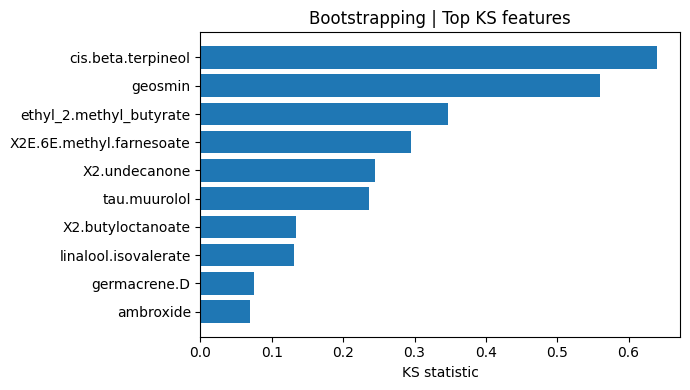

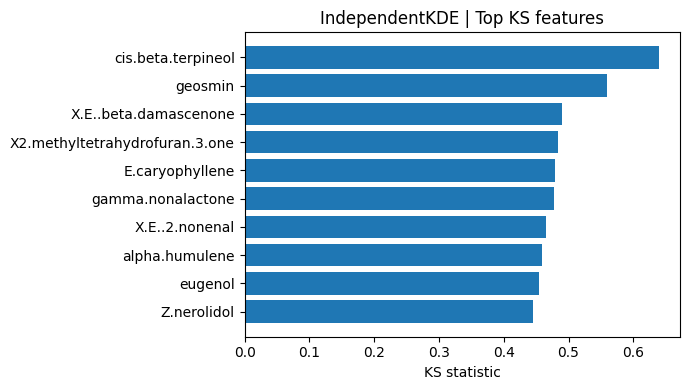

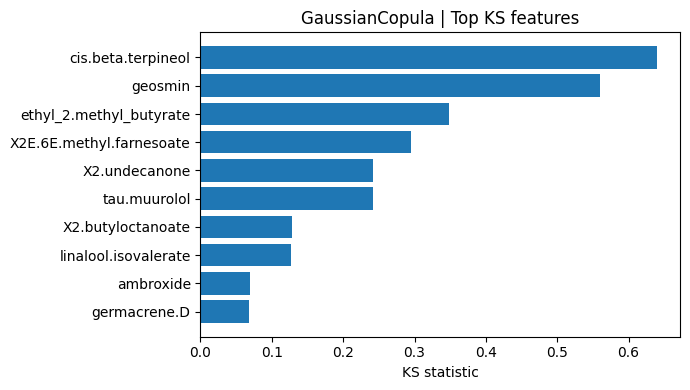

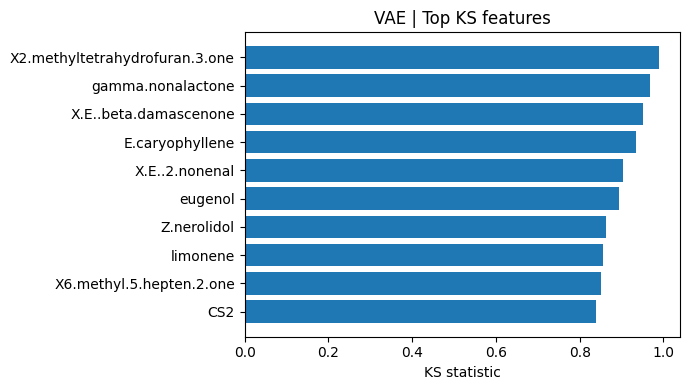

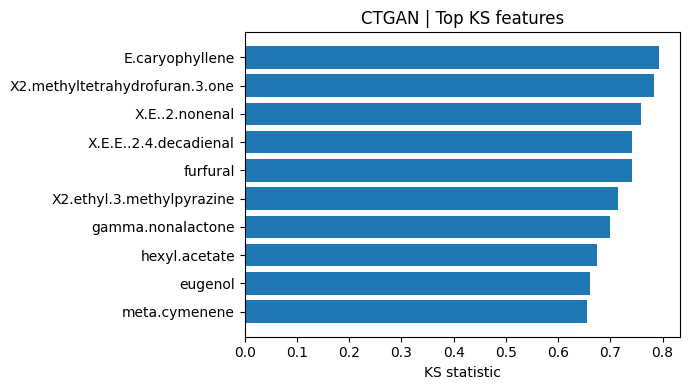

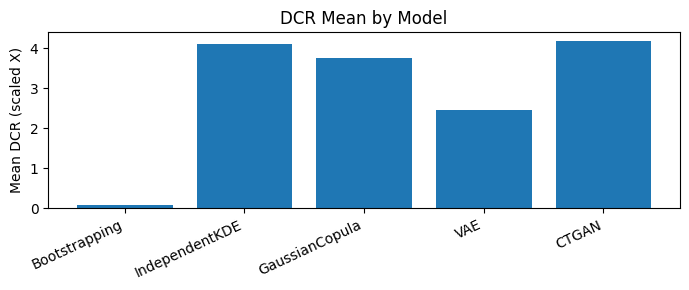

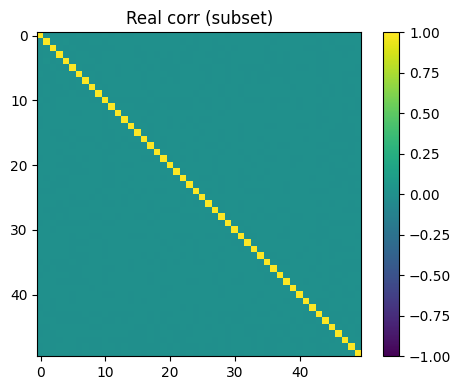

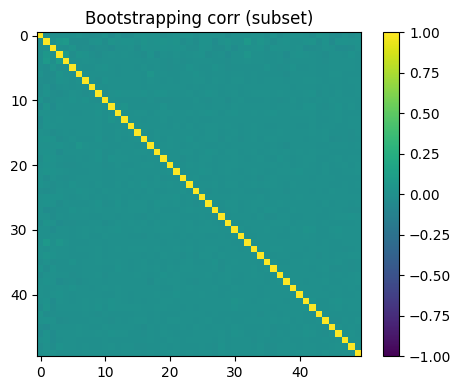

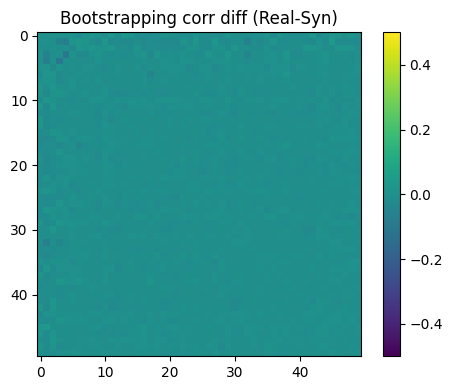

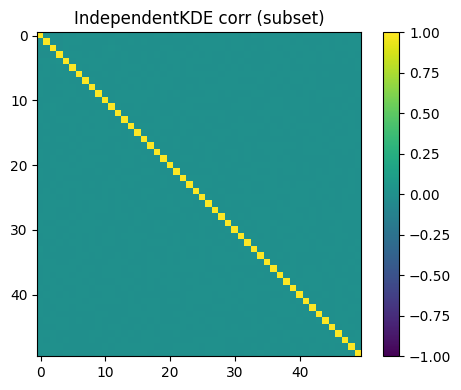

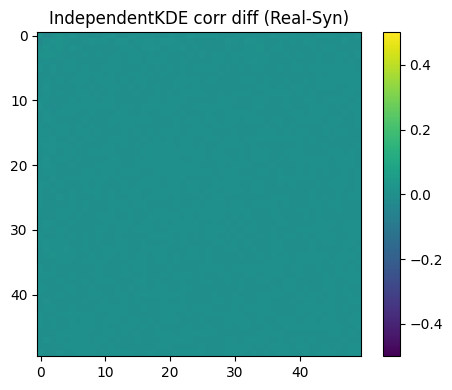

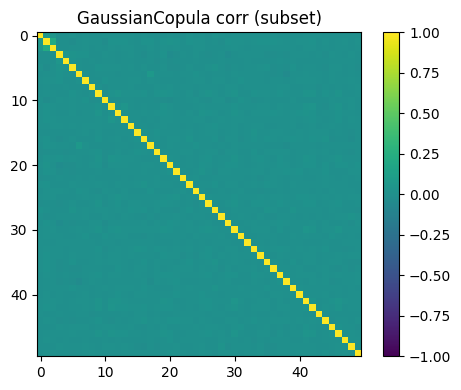

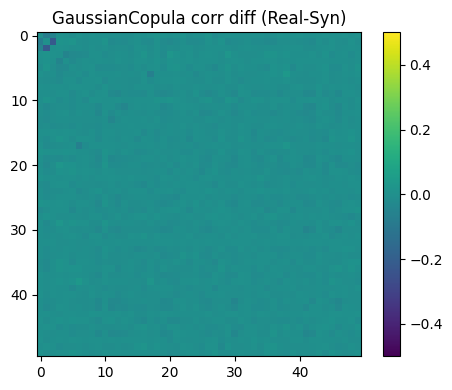

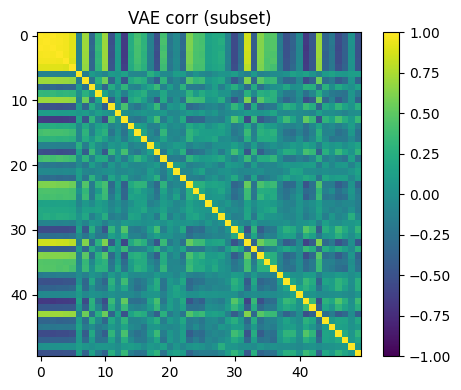

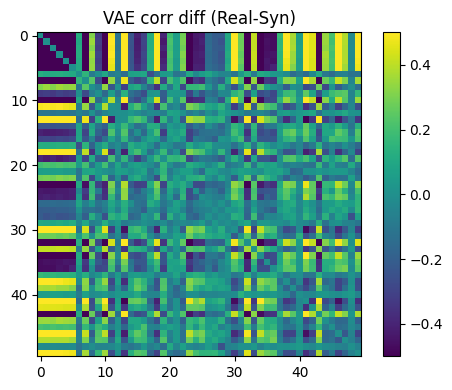

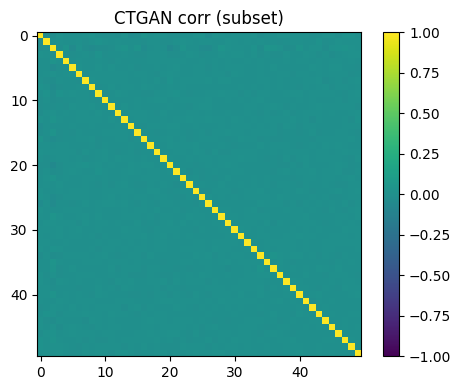

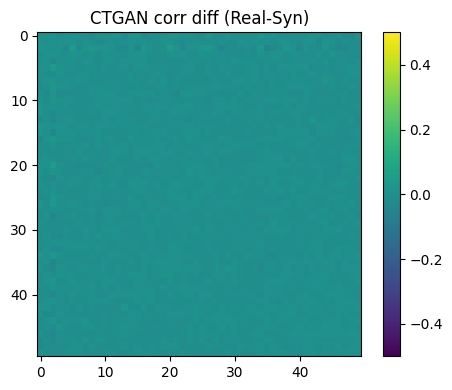

In [18]:

def plot_top_ks(ks_df, topk=10, title=""):
    dfp = ks_df.sort_values("ks_stat", ascending=False).head(topk)
    plt.figure(figsize=(7, 4))
    plt.barh(dfp["feature"][::-1], dfp["ks_stat"][::-1])
    plt.xlabel("KS statistic")
    plt.title(title or f"Top-{topk} KS")
    plt.tight_layout()
    plt.show()

def plot_dcr_means(dcr_tables):
    names = list(dcr_tables.keys())
    vals = [dcr_tables[n]["dcr_syn_mean"] for n in names]
    plt.figure(figsize=(7, 3))
    plt.bar(names, vals)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("Mean DCR (scaled X)")
    plt.title("DCR Mean by Model")
    plt.tight_layout()
    plt.show()

def plot_corr_heatmap(C, title, vmax=1.0):
    plt.figure(figsize=(5,4))
    plt.imshow(C, vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

display(results_df)

# KS top
for name, ks_df in ks_tables.items():
    plot_top_ks(ks_df, topk=10, title=f"{name} | Top KS features")

# DCR
plot_dcr_means(dcr_tables)

# Correlation subset (top-variance features in train_pcd)
var = np.var(X_train_pcd, axis=0)
top_idx = np.argsort(var)[::-1][:50]

C_real = pcd_tables[synths[0].name]["C_real"][np.ix_(top_idx, top_idx)]
plot_corr_heatmap(C_real, "Real corr (subset)", vmax=1.0)

for syn in synths:
    C_syn = pcd_tables[syn.name]["C_syn"][np.ix_(top_idx, top_idx)]
    plot_corr_heatmap(C_syn, f"{syn.name} corr (subset)", vmax=1.0)

    C_diff = pcd_tables[syn.name]["C_diff"][np.ix_(top_idx, top_idx)]
    plot_corr_heatmap(C_diff, f"{syn.name} corr diff (Real-Syn)", vmax=0.5)

## 12. (권장) Repeated Seeds로 평균±표준편차 보고
Small N에서는 결과 분산이 크므로, 논문 본문 표에는 평균±표준편차를 권장합니다.

아래는 기본 뼈대입니다(시간이 오래 걸릴 수 있음).

In [19]:

# OPTIONAL: Repeat experiment for stability (fast version: only VAE vs Copula)
DO_REPEATS = False
REPEATS = 5

if DO_REPEATS:
    selected = [
        GaussianCopulaSynthesizer(seed=0),
        VAESynthesizer(seed=0),
    ]
    rows = []
    for r in range(REPEATS):
        seed_everything(100 + r)

        # split again with different seed (stratify 유지)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_raw, y_raw, test_size=0.2, random_state=100+r, stratify=strat
        )
        pre_r = BeerPreprocessor(mode=MODE).fit(X_tr, y_tr)
        X_tr_s, X_te_s = pre_r.transform_X(X_tr), pre_r.transform_X(X_te)
        y_tr_s, y_te_s = pre_r.transform_y(y_tr), pre_r.transform_y(y_te)

        for syn in selected:
            syn.seed = 100 + r if hasattr(syn, "seed") else None
            syn.fit(X_tr_s, y_tr_s)
            Xs_syn, ys_syn = syn.sample(N_SYNTH)
            tstr = tstr_torch_mlp(Xs_syn, ys_syn, X_te_s, y_te_s, seed=100+r)
            rows.append({"repeat": r, "model": syn.name, **tstr})

    rep_df = pd.DataFrame(rows)
    display(rep_df)
    display(rep_df.groupby("model")[["r2_mean","rmse_mean"]].agg(["mean","std"]))